# Sampling methods for transfer learning

Choosing a sampling method is split into 2 parts:

- What descriptor to use? E.g. bond length, bond angles. 

- What selector algorithm to use? I.e. what distribution of descriptors do we want to select?

## 0.1. Imports and load data

In [68]:
import ase.io
import os
from pathlib import Path
import numpy as np
import importlib
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from mace import modules
from mace.data.atom_data_loader import AtomDataLoaderBuilder
from mace.testing import Tester
from mace.training import FreezeStrategy, NaiveStrategy, Trainer, initialise_autoencoder

import sampling_methods.descriptors as descriptors
import sampling_methods.selectors as selectors
import utils.training as training

importlib.reload(descriptors)
importlib.reload(selectors)
importlib.reload(training)


<module 'utils.training' from '/home/lim_yt/X-MACE-sampling/utils/training.py'>

In [69]:
MAX_EPOCHS = 10
R_MAX = 5.0
BATCH_SIZE = 16
BASE_LR = 1.0e-3
TRANSFER_LR = 5.0e-4
DEVICE = torch.device("cpu")

# define wrapper classes
trainer = Trainer(
    max_epochs=MAX_EPOCHS, early_stopping=True, patience=15,
    restore_best=True, device=DEVICE, verbose=True,
)
data_builder = AtomDataLoaderBuilder(
    cutoff=R_MAX, energy_key="REF_energy", forces_key="REF_forces"
)
tester = Tester(device=DEVICE)
loss_fn = modules.InvariantsWeightedEnergyForcesNacsDipoleLoss(
    energy_weight=1.0, forces_weight=5.0, dipoles_weight=0.0,
    nacs_weight=0.0, socs_weight=0.0,
).to(DEVICE)


In [70]:
ROOT_PATH = Path.cwd()
DATA_DIR = ROOT_PATH / "../data"

# dataset for training the base model, ie foundation/pre-trained model
BASE_XYZ = DATA_DIR / "A02_propene_grid_static.xyz"
BASE_N_GEOMETRIES = '500'  # number of geometries to use from the base dataset

# dataset for transfer learning
TRANSFER_XYZ = DATA_DIR / "casscf_44_propene_full.xyz"
TRANSFER_N_GEOMETRIES = '500' # number of geometries to use from the transfer dataset

OUTPUT_DIR = ROOT_PATH / "../outputs"

base_atoms_list = ase.io.read(BASE_XYZ, index=f":{BASE_N_GEOMETRIES}")
transfer_atoms_list = ase.io.read(TRANSFER_XYZ, index=f":{TRANSFER_N_GEOMETRIES}")

print("base_atoms_list length:", len(base_atoms_list))
print("transfer_atoms_list length:", len(transfer_atoms_list))

base_atoms_list length: 500
transfer_atoms_list length: 500


## 0.2. Split into test, train, valid sets

In [71]:
# get bond lengths and dihedrals
# tested on propene only

desc_matrix = []
bond_lengths = []
dihedrals = []

for atom in base_atoms_list:
    bond_length = descriptors.get_descriptor("bond_lengths",atom)[0]
    dihedral = descriptors.get_descriptor("dihedral",atom)[0]
    
    bond_lengths.append(bond_length)
    dihedrals.append(dihedral)
    desc_matrix.append([bond_length, dihedral])

desc_matrix = np.asarray(desc_matrix)

print("Number of unique bond lengths:", len(np.unique(bond_lengths)))
print("Number of unique dihedral angles:", len(np.unique(dihedrals)))


Number of unique bond lengths: 41
Number of unique dihedral angles: 90


In [72]:
# extract test set
# the same test set is removed from both base and transfer datasets

TEST_SET_FRACTION = 0.1
TEST_SET_SIZE = int(np.floor(int(BASE_N_GEOMETRIES) * TEST_SET_FRACTION))

test_set_idx = selectors.get_selector("uniform_grid", desc_matrix, TEST_SET_SIZE)
base_test_set = [base_atoms_list[i] for i in test_set_idx]
transfer_test_set = [transfer_atoms_list[i] for i in test_set_idx]
print("Test set size:", len(base_test_set))

# remaining geometries are for training and validation
train_valid_set_idx = np.setdiff1d(np.arange(len(transfer_atoms_list)), test_set_idx)
base_train_valid_set = [base_atoms_list[i] for i in train_valid_set_idx]
transfer_train_valid_set = [transfer_atoms_list[i] for i in train_valid_set_idx]


Test set size: 49


In [73]:
# split remaining geometries into train and valid sets
# the same for both base and transfer datasets

SEED = 42 # set as int to get the same split every time
VALID_SET_FRACTION = 0.1 # as a fraction of the total dataset

train_set_idx, valid_set_idx = train_test_split(
    train_valid_set_idx, test_size=VALID_SET_FRACTION/(1-TEST_SET_FRACTION), random_state=SEED, shuffle=True
)

base_train_set = [base_atoms_list[i] for i in train_set_idx]
print("Base train set size:", len(base_train_set))
base_valid_set = [base_atoms_list[i] for i in valid_set_idx]
print("Base valid set size:", len(base_valid_set))

transfer_train_set = [transfer_atoms_list[i] for i in train_set_idx]
print("\nFull high-fidelity train set size:", len(transfer_train_set))
transfer_valid_set = [transfer_atoms_list[i] for i in valid_set_idx]
print("Full high-fidelity valid set size:", len(transfer_valid_set))


Base train set size: 400
Base valid set size: 51

Full high-fidelity train set size: 400
Full high-fidelity valid set size: 51


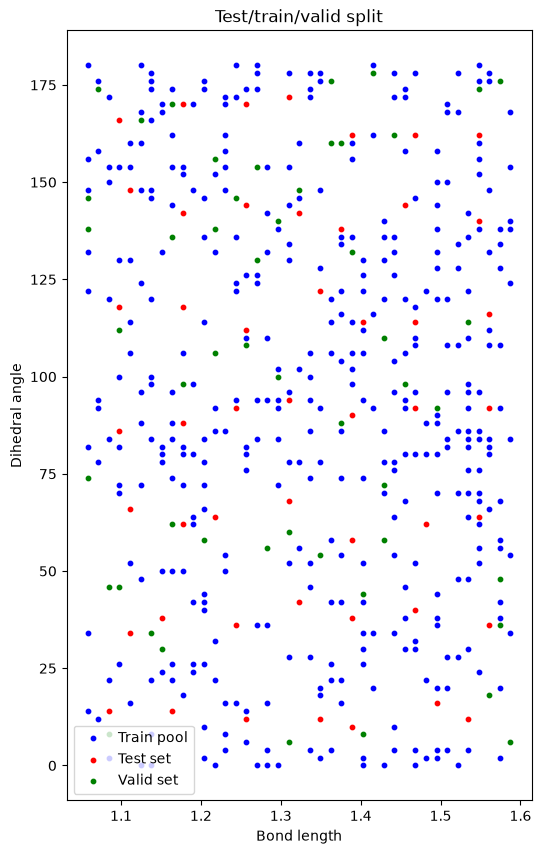

In [74]:
# visualise
plt.figure(figsize=(6, 10))  

plt.scatter([bond_lengths[i] for i in train_set_idx],
            [dihedrals[i] for i in train_set_idx], 
            color='blue', marker='o', s=10, label='Train pool')

plt.scatter([bond_lengths[i] for i in test_set_idx], 
            [dihedrals[i] for i in test_set_idx], 
            color='red', marker='o', s=10, label='Test set')

plt.scatter([bond_lengths[i] for i in valid_set_idx], 
            [dihedrals[i] for i in valid_set_idx], 
            color='green', marker='o', s=10, label='Valid set')

plt.title("Test/train/valid split")
plt.xlabel("Bond length")
plt.ylabel("Dihedral angle")
plt.legend()

plt.show()

## 0.3. Train base model



In [75]:
base_train_loader = data_builder.load(
    base_train_set, batch_size=BATCH_SIZE, shuffle=True
)
base_valid_loader = data_builder.load(
    base_valid_set, batch_size=BATCH_SIZE, shuffle=False
)
base_test_loader = data_builder.load(
    base_test_set, batch_size=BATCH_SIZE, shuffle=False
)
torch.manual_seed(SEED)

base_model = initialise_autoencoder(data_builder.get_metadata(), preset="lightweight")
base_optimizer = torch.optim.Adam(base_model.parameters(), lr=BASE_LR)

base_model, base_history = trainer.train_model(
    base_model, base_train_loader, base_valid_loader, base_optimizer, loss_fn
)

tester.run_test(base_model, base_test_loader)
base_energy_mae = tester.get_energy_mae()
{"best_epoch": base_history["best_epoch"], "test_energy_mae_ev": base_energy_mae}


/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3

Epoch 001 | train_loss=110.805522 | valid_loss=143.645348
Epoch 002 | train_loss=98.711857 | valid_loss=123.440926
Epoch 003 | train_loss=59.361273 | valid_loss=40.050778
Epoch 004 | train_loss=36.559696 | valid_loss=30.456585
Epoch 005 | train_loss=34.779711 | valid_loss=26.838164
Epoch 006 | train_loss=30.554280 | valid_loss=25.200441
Epoch 007 | train_loss=28.726743 | valid_loss=25.720980
Epoch 008 | train_loss=27.143945 | valid_loss=23.137841
Epoch 009 | train_loss=26.230271 | valid_loss=22.065236
Epoch 010 | train_loss=24.822448 | valid_loss=23.055558


{'best_epoch': 9, 'test_energy_mae_ev': 1.396447777748108}

In [ ]:
# save model
base_model_filename = "base_model_propene_500_geometries_for_pca_testing.pt"
base_model_save_path = OUTPUT_DIR / "base_models" / base_model_filename
torch.save(base_model, base_model_save_path)
print(f"Base model saved to {base_model_save_path}")


Base model saved to /home/lim_yt/X-MACE-sampling/notebooks/../outputs/base_models/base_model_propene_500_geometries_for_pca_testing.pt


## 0.4. Train full high-fidelity model
This model is the 'score to beat'

In [ ]:
full_train_loader = data_builder.load(
    transfer_train_set, batch_size=BATCH_SIZE, shuffle=True
)
full_valid_loader = data_builder.load(
    transfer_valid_set, batch_size=BATCH_SIZE, shuffle=False
)
full_test_loader = data_builder.load(
    transfer_test_set, batch_size=BATCH_SIZE, shuffle=False
)
torch.manual_seed(SEED)

full_model = initialise_autoencoder(data_builder.get_metadata(), preset="lightweight")
full_optimizer = torch.optim.Adam(full_model.parameters(), lr=BASE_LR)

full_model, full_history = trainer.train_model(
    full_model, full_train_loader, full_valid_loader, full_optimizer, loss_fn
)

tester.run_test(full_model, full_test_loader)
full_energy_mae = tester.get_energy_mae()
{"best_epoch": full_history["best_epoch"], "test_energy_mae_ev": full_energy_mae}


/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3

Epoch 001 | train_loss=94.904102 | valid_loss=119.860880
Epoch 002 | train_loss=84.474717 | valid_loss=109.148542
Epoch 003 | train_loss=53.176905 | valid_loss=48.541002
Epoch 004 | train_loss=27.624378 | valid_loss=31.212766
Epoch 005 | train_loss=18.762071 | valid_loss=15.582089
Epoch 006 | train_loss=14.415555 | valid_loss=17.797345
Epoch 007 | train_loss=14.346227 | valid_loss=12.305853
Epoch 008 | train_loss=12.969827 | valid_loss=14.237790
Epoch 009 | train_loss=12.972388 | valid_loss=12.882774
Epoch 010 | train_loss=12.906608 | valid_loss=10.831171


{'best_epoch': 10, 'test_energy_mae_ev': 0.7198627591133118}

## 1. Choose descriptor

In [98]:
DESCRIPTOR_TYPE = ["bond_lengths", "bond_angles", "dihedral", "energies", "encoded_energies", "soap", "acsf", "mbtr"]
DESCRIPTOR = DESCRIPTOR_TYPE[7]  # choose the descriptor type to use

base_encoder = base_model.perm_encoder

# matrix of descriptors for each geometry
# sampling is done on base dataset, out of the training pool only
# ie test and valid sets are already removed
desc_matrix = []
for atom in base_train_set:
    desc_matrix.append(descriptors.get_descriptor(DESCRIPTOR,atom,base_encoder))
desc_matrix = np.asarray(desc_matrix)

# n*m, where n is the number of geometries and m is the dimension of the descriptor
# eg if we use bond_lengths and propene, m=2 because there's 2 CC bonds in propene
print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)


/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/site-packages/dscribe/core/system.py:96: FutureWarning: Please use atoms.calc
  calculator=atoms.get_calculator(),


desc_matrix shape: (400, 765)
desc_matrix unique shape: (400, 765)
desc_matrix:
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [103]:
# run this to use latent space as descriptor

from mace.testing import extract_latent_space

base_train_loader_unshuffle = data_builder.load(
    base_train_set, batch_size=BATCH_SIZE, shuffle=False
)
latent_space = extract_latent_space(
    base_model, base_train_loader_unshuffle, device=DEVICE
)

desc_matrix = latent_space
print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)

desc_matrix shape: (400, 16)
desc_matrix unique shape: (400, 16)
desc_matrix:
 [[-1.5216693   0.13421759 -0.77837443 ... -1.3956807   3.1393943
   1.5304707 ]
 [-1.523548    0.1332658  -0.7784626  ... -1.3935603   3.134028
   1.5284303 ]
 [-1.5731269   0.22831844 -0.84196955 ... -1.3283169   3.1342967
   1.4212309 ]
 ...
 [-1.5251999   0.13785027 -0.7811985  ... -1.3908033   3.132894
   1.5228235 ]
 [-1.6004163   0.26048136 -0.86730736 ... -1.2925972   3.1294158
   1.3797204 ]
 [-1.5304098   0.14212975 -0.7850682  ... -1.3853344   3.1289387
   1.515557  ]]


In [ ]:
# optional dimensionality reduction using PCA

PCA_DIMENSIONS = 3

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

desc_matrix_scaled = StandardScaler().fit_transform(desc_matrix)

pca = PCA(n_components=PCA_DIMENSIONS)
desc_matrix = pca.fit_transform(desc_matrix_scaled)

print("desc_matrix shape:", desc_matrix.shape)
print("desc_matrix unique shape:", np.unique(desc_matrix, axis=0).shape)
print("desc_matrix:\n", desc_matrix)

desc_matrix shape: (500, 3)
desc_matrix unique shape: (500, 3)
desc_matrix:
 [[ 25.66290073  -7.5435525    3.57461524]
 [-17.68889132  -1.97186744 -11.88806588]
 [ -9.68128667   8.30790249  11.93837659]
 ...
 [ -4.73528134  13.40840203  -1.75137886]
 [ -0.93051678  -9.05129291  -4.19616038]
 [ -3.10642808 -11.28432425  -3.91061191]]


## 2. Choose selector

In [105]:
SELECTOR_TYPE = ["random_sampling", "farthest_point_sampling", "k_means_clustering", "k_means_clustering_weighted", "birch", "birch_weighted", "dbscan", "dbscan_weighted"]
SELECTOR = SELECTOR_TYPE[1]  # choose the selector type to use

# number of samples to select from the transfer dataset
N_SAMPLES = 100

# select samples based on the descriptor matrix
sampled_idx = selectors.get_selector(SELECTOR, desc_matrix, N_SAMPLES)

# sample atoms out of transfer dataset
sampled_atoms = [transfer_train_set[i] for i in sampled_idx]

print("sampled indices:\n", sampled_idx)
print("number sampled:", len(sampled_idx))

sampled indices:
 [  0 318  60  45 373  23  55 202 278 275 150 314 369 319 166  85 380 107
 389 315 138 155 297 242  46 393 396 346 359 105  82 102  59 171  92 285
 294 329 232 161 363   5 250 292 187 382 384 103 317 282 168 124  16  65
 183 191 362 156 371 244 259 251 112 313 173 334 192 235 243 269 337 273
 370  96 152 293 336  47   9  51 219 222 236 311 386 174 193 391   7 214
 101 398   1 207 310 374  24 256 392  21]
number sampled: 100


## 3. Do transfer learning 

Only testing with naive transfer learning for now.

In [ ]:
# this will overwrite the base model from the previous section
# run this to load the base model from file instead of using previous section

base_model_filename = "base_model_propene_500_geometries.pt"
base_model_save_path = OUTPUT_DIR / "base_models" / base_model_filename
base_model = torch.load(base_model_save_path, weights_only=False)

base_model.eval()

NameError: name 'base_model_training_result' is not defined

In [102]:
transfer_train_loader = data_builder.load(
    sampled_atoms, batch_size=BATCH_SIZE, shuffle=True
)
full_valid_loader = data_builder.load(
    transfer_valid_set, batch_size=BATCH_SIZE, shuffle=False
)
full_test_loader = data_builder.load(
    transfer_test_set, batch_size=BATCH_SIZE, shuffle=False
)

transfer_model = NaiveStrategy().apply(base_model)
transfer_optimizer = torch.optim.Adam(transfer_model.parameters(), lr=TRANSFER_LR)

torch.manual_seed(SEED)

transfer_model, transfer_history = trainer.train_model(
    transfer_model, transfer_train_loader, full_valid_loader, transfer_optimizer, loss_fn
)

tester.run_test(transfer_model, full_test_loader)
transfer_energy_mae = tester.get_energy_mae()
{"best_epoch": transfer_history["best_epoch"], "test_energy_mae_ev": transfer_energy_mae}


Epoch 001 | train_loss=16.810898 | valid_loss=14.140697
Epoch 002 | train_loss=11.323155 | valid_loss=10.718214
Epoch 003 | train_loss=9.795982 | valid_loss=10.401622
Epoch 004 | train_loss=10.002962 | valid_loss=10.164481
Epoch 005 | train_loss=9.335433 | valid_loss=10.037941
Epoch 006 | train_loss=9.472002 | valid_loss=11.802254
Epoch 007 | train_loss=9.682687 | valid_loss=9.676462
Epoch 008 | train_loss=8.830259 | valid_loss=10.237324
Epoch 009 | train_loss=9.245996 | valid_loss=12.062723
Epoch 010 | train_loss=9.210354 | valid_loss=10.496307


{'best_epoch': 7, 'test_energy_mae_ev': 0.7109026312828064}

In [ ]:
# save model
transfer_model_filename = "transfer_model_propene_100_samples.pt"
transfer_model_save_path = OUTPUT_DIR / "transfer_models" / transfer_model_filename
torch.save(transfer_model, transfer_model_save_path)
print(f"Transfer model saved to {transfer_model_save_path}")

## 4. Loss plots

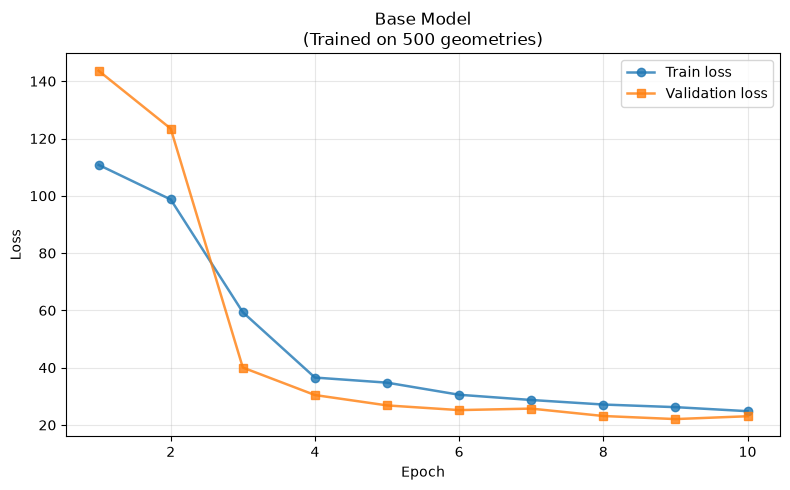

In [66]:
import matplotlib.pyplot as plt

# Plot base model training history
base_epochs = base_history['epoch']
base_train_losses = base_history['train_loss']
base_valid_losses = base_history['valid_loss']

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(base_epochs, base_train_losses, marker="o", linewidth=1.8, label="Train loss", alpha=0.8)
ax.plot(base_epochs, base_valid_losses, marker="s", linewidth=1.8, label="Validation loss", alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"Base Model\n(Trained on {BASE_N_GEOMETRIES} geometries)")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

# save plot
# BASE_LOSS_PLOT_PATH = OUTPUT_DIR / "plots" / "base_model_propene_500_geometries.png"
# fig.savefig(BASE_LOSS_PLOT_PATH, dpi=150)

plt.show()

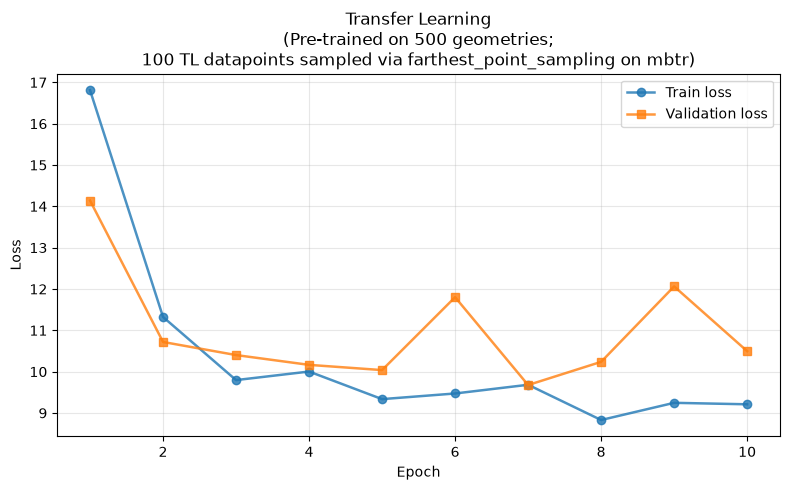

In [106]:
# Plot transfer learning training history
transfer_epochs = transfer_history['epoch']
transfer_train_losses = transfer_history['train_loss']
transfer_valid_losses = transfer_history['valid_loss']

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(transfer_epochs, transfer_train_losses, marker="o", linewidth=1.8, label="Train loss", alpha=0.8)
ax.plot(transfer_epochs, transfer_valid_losses, marker="s", linewidth=1.8, label="Validation loss", alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
if SELECTOR == 'random_sampling':
    ax.set_title(f"Transfer Learning\n(Pre-trained on {BASE_N_GEOMETRIES} geometries;\n{N_SAMPLES} TL datapoints sampled via {SELECTOR})")
else:
    ax.set_title(f"Transfer Learning\n(Pre-trained on {BASE_N_GEOMETRIES} geometries;\n{N_SAMPLES} TL datapoints sampled via {SELECTOR} on {DESCRIPTOR})")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

# save plot
# TRANSFER_LOSS_PLOT_PATH = OUTPUT_DIR / "plots" / "transfer_model_propene_100_samples.png"
# fig.savefig(TRANSFER_LOSS_PLOT_PATH, dpi=150)

plt.show()


## 5. Error plots

In [67]:
categories = ['Base model', 'Full HF model', 'Transfer model']
values = [base_energy_mae, full_energy_mae, transfer_energy_mae]
colors = ["#377eb8", "#ff7f00", "#fdbf6f", "#4daf4a", "#a6d854"]

fig, ax = plt.subplots()
bars = ax.bar(categories, values, color=colors)
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.set_ylabel("Mean energy MAE, eV")
ax.set_title("Multi-fidelity Transfer Learning")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

plt.show()


NameError: name 'full_energy_mae' is not defined

## 6. Junkyard

In [ ]:
# run this to use the base model from the previous section
transfer_model_training_result = training.train_model(
    sampled_atoms,
    model=base_model,
    z_table=z_table,
    max_epochs=10,
)

transfer_history = transfer_model_training_result.history
transfer_model = transfer_model_training_result.model

{'stage': 'base_model', 'epoch': 1, 'train_loss': 14.070414972305297, 'valid_loss': 8.573455810546875, 'seconds': 4.49}
{'stage': 'base_model', 'epoch': 5, 'train_loss': 10.668433165550232, 'valid_loss': 9.404039764404297, 'seconds': 5.69}
{'stage': 'base_model', 'epoch': 10, 'train_loss': 8.446242761611938, 'valid_loss': 8.121990394592284, 'seconds': 5.7}

Training complete after 10 epochs
Final train loss: 8.446243
Final valid loss: 8.121990


In [ ]:
base_model_training_result = training.train_model(
    base_train_valid_set,
    max_epochs=10
)

base_model = base_model_training_result.model
z_table = base_model_training_result.z_table
base_history = base_model_training_result.history
base_encoder = base_model_training_result.encoder

/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3

{'stage': 'base_model', 'epoch': 1, 'train_loss': 108.76530412527231, 'valid_loss': 95.35587285912555, 'seconds': 21.88}
{'stage': 'base_model', 'epoch': 5, 'train_loss': 31.252223800826858, 'valid_loss': 23.76442983876104, 'seconds': 22.76}
{'stage': 'base_model', 'epoch': 10, 'train_loss': 22.996510903913897, 'valid_loss': 23.212563639101774, 'seconds': 26.99}

Training complete after 10 epochs
Final train loss: 22.996511
Final valid loss: 23.212564


In [ ]:
def add_autoencoder_targets(active_model, batch, output):
    """Add autoencoder targets to output for loss computation."""
    centred_reference_energy = (
        batch["energy"] - output["e0s"] - output["pair_energy"]
    ).unsqueeze(-1)
    
    output["encoded_energy"] = active_model.perm_encoder(centred_reference_energy)
    output["decoded_energy"] = (
        active_model.perm_decoder(output["encoded_energy"])
        + output["e0s"]
        + output["pair_energy"]
    )
    return output

In [9]:
import copy
import time
import torch
from mace import data, modules, tools
from mace.tools import torch_geometric
from e3nn import o3

DEVICE = torch.device("cpu")
SEED = 123
np.random.seed(SEED)
torch.manual_seed(SEED)

# Base model training parameters
BASE_MODEL_MAX_EPOCHS = 50
BASE_MODEL_LR = 1.0e-3
BATCH_SIZE = 4
R_MAX = 5.0
BASE_VALID_FRACTION = 0.20

example_atom = base_atoms_list[0]
N_ENERGIES = np.asarray(example_atom.info["REF_energy"]).shape[-1]

print(f"Energy shape: {np.asarray(example_atom.info['REF_energy']).shape}")
print(f"Forces shape: {np.asarray(example_atom.info['REF_forces']).shape}")
print(f"N_ENERGIES: {N_ENERGIES}")


Energy shape: (1, 3)
Forces shape: (6, 3, 3)
N_ENERGIES: 3


In [20]:
# Create MACE Configuration objects from all atoms
base_atoms_configs = data.config_from_atoms_list(
    base_atoms_list,
    energy_key="REF_energy",
    forces_key="REF_forces",
    config_type_weights={"Default": 1.0},
)

# Split into train/validation
base_train_configs, base_valid_configs = data.random_train_valid_split(
    base_atoms_configs,
    valid_fraction=BASE_VALID_FRACTION,
    seed=SEED,
    work_dir=str(OUTPUT_DIR/"random_train_valid_split"),
)

print(f"Train configs: {len(base_train_configs)}")
print(f"Valid configs: {len(base_valid_configs)}")


Train configs: 80
Valid configs: 20


In [11]:
# Create atomic number table and compute atomic energies
z_table = tools.get_atomic_number_table_from_zs(
    z for config in base_atoms_configs for z in config.atomic_numbers
)

atomic_energies_dict = data.compute_average_E0s(base_train_configs, z_table)
atomic_energies = np.array([atomic_energies_dict[z] for z in z_table.zs], dtype=np.float64)

print(f"Atomic numbers: {[int(z) for z in z_table.zs]}")
print("Estimated E0s:", {int(k): float(v) for k, v in atomic_energies_dict.items()})

Atomic numbers: [1, 6]
Estimated E0s: {1: -423.28382858346106, 6: -211.6419142917305}


In [12]:
# Convert Configuration objects to graph data objects
base_train_set = [
    data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
    for config in base_train_configs
]
base_valid_set = [
    data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
    for config in base_valid_configs
]

# Create data loaders
base_train_loader = torch_geometric.dataloader.DataLoader(
    base_train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)
base_valid_loader = torch_geometric.dataloader.DataLoader(
    base_valid_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)

avg_num_neighbors = modules.compute_avg_num_neighbors(base_train_loader)
print(f"Average neighbors: {float(avg_num_neighbors)}")


Average neighbors: 5.0


In [13]:
# Build the base model
base_model = modules.AutoencoderExcitedMACE(
    r_max=R_MAX,
    num_bessel=4,
    num_polynomial_cutoff=3,
    num_permutational_invariant=4,
    n_energies=N_ENERGIES,
    max_ell=2,
    interaction_cls=modules.interaction_classes["RealAgnosticResidualInteractionBlock"],
    interaction_cls_first=modules.interaction_classes["RealAgnosticResidualInteractionBlock"],
    num_interactions=1,
    num_elements=len(z_table),
    hidden_irreps=o3.Irreps("4x0e + 4x1o"),
    MLP_irreps=o3.Irreps("4x0e"),
    atomic_energies=atomic_energies,
    avg_num_neighbors=float(avg_num_neighbors),
    atomic_numbers=[int(z) for z in z_table.zs],
    correlation=1,
    gate=modules.gate_dict["silu"],
    radial_MLP=[32, 32],
    compute_nacs=False,
    compute_socs=False,
    nac_num=0,
    soc_num=0,
).to(DEVICE)

print(f"Base model class: {base_model.__class__.__name__}")
print(f"Total parameters: {tools.count_parameters(base_model)}")


/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)


Base model class: AutoencoderExcitedMACE
Total parameters: 54269


/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)
/home/lim_yt/micromamba/envs/xmace311/lib/python3

In [14]:
loss_fn = modules.InvariantsWeightedEnergyForcesNacsDipoleLoss(
    energy_weight=1.0,
    forces_weight=5.0,
    dipoles_weight=0.0,
    nacs_weight=0.0,
    socs_weight=0.0,
)

def add_autoencoder_targets(active_model, batch, output):
    """Add autoencoder targets to output for loss computation."""
    centred_reference_energy = (
        batch["energy"] - output["e0s"] - output["pair_energy"]
    ).unsqueeze(-1)
    
    output["encoded_energy"] = active_model.perm_encoder(centred_reference_energy)
    output["decoded_energy"] = (
        active_model.perm_decoder(output["encoded_energy"])
        + output["e0s"]
        + output["pair_energy"]
    )
    return output

optimizer = torch.optim.Adam(base_model.parameters(), lr=BASE_MODEL_LR)


In [15]:
base_history = []

for epoch in range(BASE_MODEL_MAX_EPOCHS):
    epoch_start = time.time()
    base_model.train()
    train_losses = []

    for batch in base_train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        output = base_model(
            batch.to_dict(),
            training=True,
            compute_force=True,
            compute_virials=False,
            compute_stress=False,
        )
        output = add_autoencoder_targets(base_model, batch, output)

        loss = loss_fn(ref=batch, pred=output)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(base_model.parameters(), max_norm=10.0)
        optimizer.step()
        train_losses.append(float(loss.detach().cpu()))

    base_model.eval()
    valid_losses = []
    for batch in base_valid_loader:
        batch = batch.to(DEVICE)
        output = base_model(
            batch.to_dict(),
            training=False,
            compute_force=True,
            compute_virials=False,
            compute_stress=False,
        )
        output = add_autoencoder_targets(base_model, batch, output)

        loss = loss_fn(ref=batch, pred=output)
        valid_losses.append(float(loss.detach().cpu()))

    row = {
        "stage": "base_model",
        "epoch": epoch + 1,
        "train_loss": float(np.mean(train_losses)),
        "valid_loss": float(np.mean(valid_losses)),
        "seconds": round(time.time() - epoch_start, 2),
    }
    base_history.append(row)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(row)

print(f"\nBase model training complete after {BASE_MODEL_MAX_EPOCHS} epochs")
print(f"Final train loss: {base_history[-1]['train_loss']:.6f}")
print(f"Final valid loss: {base_history[-1]['valid_loss']:.6f}")


{'stage': 'base_model', 'epoch': 1, 'train_loss': 133.50133457183838, 'valid_loss': 123.0882942199707, 'seconds': 4.73}
{'stage': 'base_model', 'epoch': 10, 'train_loss': 24.448433685302735, 'valid_loss': 28.93583164215088, 'seconds': 3.8}
{'stage': 'base_model', 'epoch': 20, 'train_loss': 20.233992409706115, 'valid_loss': 16.200241470336913, 'seconds': 3.66}
{'stage': 'base_model', 'epoch': 30, 'train_loss': 18.309427070617676, 'valid_loss': 17.055677795410155, 'seconds': 3.57}
{'stage': 'base_model', 'epoch': 40, 'train_loss': 15.904407215118407, 'valid_loss': 13.581294059753418, 'seconds': 3.66}
{'stage': 'base_model', 'epoch': 50, 'train_loss': 17.88831443786621, 'valid_loss': 16.37652168273926, 'seconds': 3.74}

Base model training complete after 50 epochs
Final train loss: 17.888314
Final valid loss: 16.376522


In [16]:
# Transfer learning parameters
TRANSFER_MAX_EPOCHS = 50
TRANSFER_LR = 5.0e-4
TRANSFER_VALID_FRACTION = 0.20

# Create MACE Configuration objects from selected atoms
transfer_configs = data.config_from_atoms_list(
    selected_atoms,
    energy_key="REF_energy",
    forces_key="REF_forces",
    config_type_weights={"Default": 1.0},
)

# Split selected configurations into train/validation sets
transfer_train_configs, transfer_valid_configs = data.random_train_valid_split(
    transfer_configs,
    valid_fraction=TRANSFER_VALID_FRACTION,
    seed=SEED,
    work_dir=str(ROOT_PATH),
)

print(f"Train configs: {len(transfer_train_configs)}")
print(f"Valid configs: {len(transfer_valid_configs)}")


Train configs: 40
Valid configs: 10


In [17]:
# Convert Configuration objects to graph data objects
transfer_train_set = [
    data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
    for config in transfer_train_configs
]
transfer_valid_set = [
    data.AtomicData.from_config(config, z_table=z_table, cutoff=R_MAX)
    for config in transfer_valid_configs
]

# Create data loaders for transfer learning
transfer_train_loader = torch_geometric.dataloader.DataLoader(
    transfer_train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False,
)
transfer_valid_loader = torch_geometric.dataloader.DataLoader(
    transfer_valid_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
)


In [18]:
# Make a deep copy of the base model for transfer learning
transfer_model = copy.deepcopy(base_model).to(DEVICE)
transfer_model.eval()

# Initialize optimizer for naive transfer learning (all parameters trainable)
transfer_optimizer = torch.optim.Adam(transfer_model.parameters(), lr=TRANSFER_LR)
transfer_trainable_count = sum(param.numel() for param in transfer_model.parameters() if param.requires_grad)

print(f"Transfer model class: {transfer_model.__class__.__name__}")
print(f"Transfer model parameters: {tools.count_parameters(transfer_model)}")
print(f"Transfer trainable parameters: {transfer_trainable_count}")
print(f"All parameters will be fine-tuned (naive transfer learning)")


Transfer model class: AutoencoderExcitedMACE
Transfer model parameters: 54269
Transfer trainable parameters: 54269
All parameters will be fine-tuned (naive transfer learning)


In [14]:
# Transfer learning training loop
transfer_history = []

for epoch in range(TRANSFER_MAX_EPOCHS):
    epoch_start = time.time()
    transfer_model.train()
    train_losses = []

    for batch in transfer_train_loader:
        batch = batch.to(DEVICE)
        transfer_optimizer.zero_grad(set_to_none=True)

        output = transfer_model(
            batch.to_dict(),
            training=True,
            compute_force=True,
            compute_virials=False,
            compute_stress=False,
        )
        output = add_autoencoder_targets(transfer_model, batch, output)

        loss = loss_fn(ref=batch, pred=output)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(transfer_model.parameters(), max_norm=10.0)
        transfer_optimizer.step()
        train_losses.append(float(loss.detach().cpu()))

    transfer_model.eval()
    valid_losses = []
    for batch in transfer_valid_loader:
        batch = batch.to(DEVICE)
        output = transfer_model(
            batch.to_dict(),
            training=False,
            compute_force=True,
            compute_virials=False,
            compute_stress=False,
        )
        output = add_autoencoder_targets(transfer_model, batch, output)

        loss = loss_fn(ref=batch, pred=output)
        valid_losses.append(float(loss.detach().cpu()))

    row = {
        "stage": "transfer_learning_naive",
        "epoch": epoch + 1,
        "train_loss": float(np.mean(train_losses)),
        "valid_loss": float(np.mean(valid_losses)),
        "seconds": round(time.time() - epoch_start, 2),
    }
    transfer_history.append(row)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(row)

print(f"\nTransfer learning complete after {TRANSFER_MAX_EPOCHS} epochs")
print(f"Final train loss: {transfer_history[-1]['train_loss']:.6f}")
print(f"Final valid loss: {transfer_history[-1]['valid_loss']:.6f}")


{'stage': 'transfer_learning_naive', 'epoch': 1, 'train_loss': 46.002227783203125, 'valid_loss': 77.25628662109375, 'seconds': 2.6}
{'stage': 'transfer_learning_naive', 'epoch': 10, 'train_loss': 35.377170944213866, 'valid_loss': 67.54226938883464, 'seconds': 2.42}
{'stage': 'transfer_learning_naive', 'epoch': 20, 'train_loss': 30.790317916870116, 'valid_loss': 53.913323720296226, 'seconds': 2.89}
{'stage': 'transfer_learning_naive', 'epoch': 30, 'train_loss': 28.614780044555665, 'valid_loss': 47.33015441894531, 'seconds': 2.72}
{'stage': 'transfer_learning_naive', 'epoch': 40, 'train_loss': 27.557461071014405, 'valid_loss': 44.18674087524414, 'seconds': 2.61}
{'stage': 'transfer_learning_naive', 'epoch': 50, 'train_loss': 26.280632972717285, 'valid_loss': 41.46345011393229, 'seconds': 2.54}

Transfer learning complete after 50 epochs
Final train loss: 26.280633
Final valid loss: 41.463450
